In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

## 1. Lendo o dataset

In [2]:
X = np.genfromtxt("dataset_clientes_kmeans.csv", delimiter=",", skip_header=1)

In [21]:
display(X)

array([[ 2.39737132e+00,  7.86173570e+01],
       [ 2.51815083e+00,  9.52302986e+01],
       [ 1.81267730e+00,  7.76586304e+01],
       [ 3.26337025e+00,  8.76743473e+01],
       [ 1.62442049e+00,  8.54256004e+01],
       [ 1.62926585e+00,  7.53427025e+01],
       [ 2.19356982e+00,  6.08671976e+01],
       [ 6.20065734e-01,  7.43771247e+01],
       [ 1.18973510e+00,  8.31424733e+01],
       [ 1.27358074e+00,  6.58769630e+01],
       [ 3.17251902e+00,  7.77422370e+01],
       [ 2.05402256e+00,  6.57525181e+01],
       [ 1.56449382e+00,  8.11092259e+01],
       [ 1.07920514e+00,  8.37569802e+01],
       [ 1.51948905e+00,  7.70830625e+01],
       [ 1.51863471e+00,  9.85227818e+01],
       [ 1.98920222e+00,  6.94228907e+01],
       [ 2.65803593e+00,  6.77915635e+01],
       [ 2.16709088e+00,  6.04032988e+01],
       [ 9.37451161e-01,  8.19686124e+01],
       [ 2.59077326e+00,  8.17136828e+01],
       [ 1.90748137e+00,  7.69889630e+01],
       [ 8.17182408e-01,  7.28015579e+01],
       [ 1.

## 2. Função da distância euclidiana

In [ ]:
def euclidean_distance(a, b): # calculando a distância entre dois pontos
  return np.sqrt(np.sum((a - b)**2, axis=1))

## 3. Implementação do K-Means

In [ ]:
def kmeans(X, k=3, max_iter=100): # usando o X, com 3 grupos, máximo de 100 iterações
  # 1. Inicializar centróides escolhendo k pontos aleatórios
  idx = np.random.choice(len(X), k, replace=False) # escolhe 3 (k) valores para colocar no array dentro do range do tamanho de X, sem repetir
  centroids = X[idx] # usa esses índices para pegar os pontos reais do dataset - viram os centroids

  for _ in range(max_iter): # para cada ponto do dataset com range baseado nas iterações maximas
    # 2. Associação - escolher centróide mais próximo
    clusters = [[] for _ in range(k)] # cria arrays baseado no range de k
    labels = np.zeros(len(X)) # cria array de labels começando com valores zerados

    for i, point in enumerate(X): # para cada ponto no dataset X ele calcula a distancia euclidiana (usando pontos e centroids)
      distances = euclidean_distance(point, centroids)
      label = np.argmin(distances) # pega as menores distancias para label
      clusters[label].append(point) # adiciona o ponto no cluster daquela label
      labels[i] = label 

    # 3. Guardar centróides antigos
    old_centroids = centroids.copy()

    # 4. Atualizar centróides
    for i in range(k): # para cada um em 3 (k)
      if clusters[i]: # se o grupo tem pelo menos um ponto antes de calcular
        centroids[i] = np.mean(clusters[i], axis=0) # adiciona média

    # 5. Critério de parada
    if np.allclose(centroids, old_centroids): # quando ficar igual
      break

  return centroids, labels


## 4. Executando o K-means

In [ ]:
centroids, labels = kmeans(X, k=3)

## 5. Plotar os resultados

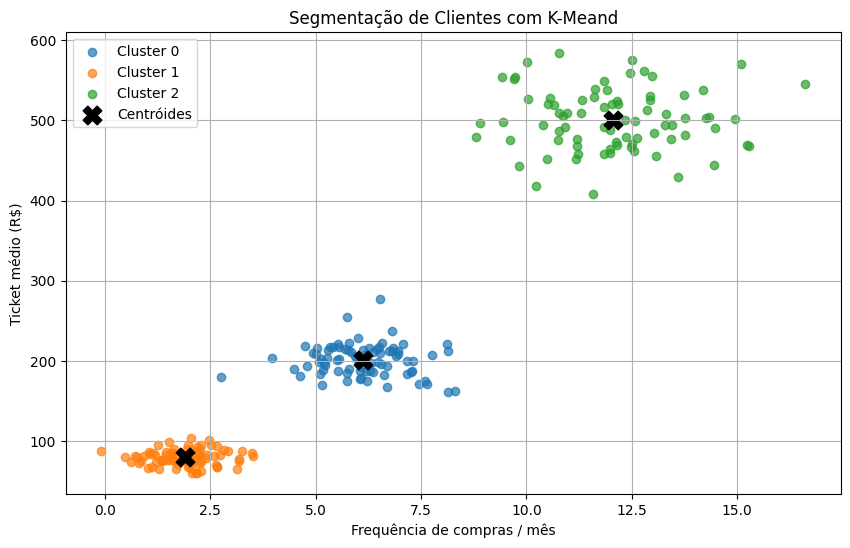

In [ ]:
plt.figure(figsize=(10, 6))

for cluster_id in np.unique(labels):
  plt.scatter(
      X[labels == cluster_id, 0], # coordenada X dos pontos pertencentes ao cluster
      X[labels == cluster_id, 1], # coordenada y dos pontos pertencentes ao cluster
      alpha=0.7,
      label=f"Cluster {int(cluster_id)}"
  )

plt.scatter(
    centroids[:, 0], centroids[:, 1], s=180, c="black", marker="X", label="Centróides"
  ) # coordenadas X e Y de todos os centroids

plt.title("Segmentação de Clientes com K-Meand")
plt.xlabel("Frequência de compras / mês")
plt.ylabel("Ticket médio (R$)")
plt.legend()
plt.grid(True)
plt.show()